# H12: Spatial Bootstrap — Region Prediction from Vessel Metrics

**Question:** Can we identify tissue regions (Follicle, PALS, RedPulp, Trabeculae)
from vessel spatial and morphological metrics alone, without region labels?

**Approach:**
1. Crop larger images to ~5000 µm windows (matching smaller tissue sections)
2. Drop random circular probes across each image's SmallVessel point cloud
3. Compute vessel metrics per circle (area fraction, NN distance, Clark-Evans, morphology)
4. Assign each circle a "dominant region" from its vessels' Parent hierarchy
5. **Phase 1 (blind):** Explore circle features with anonymous IDs — do natural groups emerge?
6. **Phase 2 (reveal):** Compare feature-based clusters to known tissue regions;
   quantify classification accuracy via Leave-One-Image-Out cross-validation

**Samples:** 15 (10 Phenocycler + 5 CODEX). Only HDL172 excluded (no genotype).

> **Caveat:** n = 3–8 per genotype group; genotype analysis is secondary and exploratory.

In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from scipy.spatial import cKDTree, ConvexHull
from scipy.cluster.hierarchy import linkage, dendrogram
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_fscore_support
from sklearn.model_selection import LeaveOneGroupOut
from matplotlib.patches import Patch

from data_utils import (
    PROJECT, DATA_CSV, CODEX_CSV,
    GENO_ORDER, GENO_PALETTE, GENOTYPE_MAP,
    extract_sample_id,
    _CODEX_CLASS_MAP, _CODEX_REGION_MAP,
    full_stats_table, setup_style, save_figure, save_table,
)

setup_style()

In [2]:
# Load AnnotationsFinal.csv directly — bypasses EXCLUDE_SAMPLES to keep HDL018/HDL021
df_main = pd.read_csv(DATA_CSV)
df_main["Sample"] = df_main["Image"].apply(extract_sample_id)
df_main["Genotype"] = df_main["Sample"].map(GENOTYPE_MAP)
df_main = df_main[df_main["Sample"] != "HDL172"]  # only exclude HDL172 (no genotype)
df_main = df_main.dropna(subset=["Genotype"])

# Load CODEX data and harmonize
codex = pd.read_csv(CODEX_CSV)
codex["Classification"] = codex["Classification"].map(
    lambda c: _CODEX_CLASS_MAP.get(c, c))
codex["Parent"] = codex["Parent"].str.replace(
    r"Annotation \((\w+)\)",
    lambda m: f"Annotation ({_CODEX_REGION_MAP.get(m.group(1), m.group(1))})",
    regex=True,
)
codex["Sample"] = codex["Image"].apply(extract_sample_id)
codex["Genotype"] = codex["Sample"].map(GENOTYPE_MAP)
codex = codex.dropna(subset=["Genotype"])

# Combine
df = pd.concat([df_main, codex], ignore_index=True)

# SmallVessel centroids with Region from Parent
vessels = df[df["Classification"] == "SmallVessel"].copy()
vessels["Region"] = vessels["Parent"].str.extract(r"Annotation \((\w+)\)")

# Keep only main tissue regions
REGIONS_OF_INTEREST = ["Follicle", "PALS", "RedPulp", "Trabeculae"]
vessels = vessels[vessels["Region"].isin(REGIONS_OF_INTEREST)]

print(f"SmallVessels in main regions: {len(vessels):,}")
print(f"Unique samples: {vessels['Sample'].nunique()}")
print(f"\nRegion distribution:")
print(vessels["Region"].value_counts().to_string())
print(f"\nPer-sample counts:")
print(vessels.groupby("Sample").size().to_string())

SmallVessels in main regions: 464,220
Unique samples: 15

Region distribution:
Region
RedPulp       389492
PALS           32126
Follicle       29171
Trabeculae     13431

Per-sample counts:
Sample
1901HBMP004     5513
HBMP006         8732
HBMP007         3204
HDL011         32026
HDL018          4897
HDL021         56760
HDL043         28308
HDL052         15984
HDL053         67338
HDL055         69747
HDL063         87461
HDL070         31316
HDL073          4754
HDL086         42962
HDL098          5218


In [3]:
# --- Crop large images to ~5000 µm window from densest area ---
CROP_SIZE = 5000  # µm
CROP_THRESHOLD = 6000  # crop if max extent exceeds this

# Collect raw per-image data
image_data_raw = {}
for sample in sorted(vessels["Sample"].unique()):
    sv = vessels[vessels["Sample"] == sample]
    coords = sv[["Centroid X µm", "Centroid Y µm"]].values
    areas = sv["Area µm^2"].values
    regions = sv["Region"].values
    image_data_raw[sample] = {
        "coords": coords, "areas": areas, "regions": regions,
        "x_extent": coords[:, 0].ptp(), "y_extent": coords[:, 1].ptp(),
    }

# Show pre-crop extents
print(f"{'Sample':16s}  {'N':>6s}  {'X_ext':>7s}  {'Y_ext':>7s}  Crop?")
print("-" * 55)
for s in sorted(image_data_raw):
    d = image_data_raw[s]
    needs_crop = max(d["x_extent"], d["y_extent"]) > CROP_THRESHOLD
    print(f"{s:16s}  {len(d['coords']):6d}  {d['x_extent']:7.0f}  {d['y_extent']:7.0f}  {'YES' if needs_crop else 'no'}")

# Crop: center on densest 5000×5000 window (200 random candidates, pick max vessel count)
rng_crop = np.random.default_rng(7)
image_data = {}

for sample, d in image_data_raw.items():
    coords, areas, regions = d["coords"], d["areas"], d["regions"]

    if max(d["x_extent"], d["y_extent"]) > CROP_THRESHOLD:
        half = CROP_SIZE / 2
        x_lo_c = coords[:, 0].min() + half
        x_hi_c = coords[:, 0].max() - half
        y_lo_c = coords[:, 1].min() + half
        y_hi_c = coords[:, 1].max() - half

        # Handle case where extent < CROP_SIZE in one dimension
        x_lo_c = min(x_lo_c, x_hi_c)
        y_lo_c = min(y_lo_c, y_hi_c)

        best_count, best_cx, best_cy = 0, np.median(coords[:, 0]), np.median(coords[:, 1])
        for _ in range(500):
            cx = rng_crop.uniform(x_lo_c, max(x_hi_c, x_lo_c + 1))
            cy = rng_crop.uniform(y_lo_c, max(y_hi_c, y_lo_c + 1))
            in_box = ((coords[:, 0] >= cx - half) & (coords[:, 0] <= cx + half) &
                      (coords[:, 1] >= cy - half) & (coords[:, 1] <= cy + half))
            cnt = in_box.sum()
            if cnt > best_count:
                best_count, best_cx, best_cy = cnt, cx, cy

        mask = ((coords[:, 0] >= best_cx - half) & (coords[:, 0] <= best_cx + half) &
                (coords[:, 1] >= best_cy - half) & (coords[:, 1] <= best_cy + half))
        coords, areas, regions = coords[mask], areas[mask], regions[mask]

    tree = cKDTree(coords)
    if len(coords) >= 3:
        hull = ConvexHull(coords)
        hull_area, hull_vertices = hull.volume, coords[hull.vertices]
    else:
        hull, hull_area, hull_vertices = None, np.nan, coords

    image_data[sample] = {
        "coords": coords, "areas": areas, "regions": regions,
        "tree": tree, "hull": hull, "hull_area": hull_area,
        "hull_vertices": hull_vertices,
        "n_vessels": len(coords),
        "x_extent": coords[:, 0].ptp(), "y_extent": coords[:, 1].ptp(),
    }

# Post-crop summary
print(f"\nPost-crop summary:")
print(f"{'Sample':16s}  {'N':>6s}  {'X_ext':>7s}  {'Y_ext':>7s}  Regions")
print("-" * 80)
for s in sorted(image_data):
    d = image_data[s]
    rc = Counter(d["regions"])
    reg_str = ", ".join(f"{r}:{c}" for r, c in rc.most_common())
    print(f"{s:16s}  {d['n_vessels']:6d}  {d['x_extent']:7.0f}  {d['y_extent']:7.0f}  {reg_str}")

Sample                 N    X_ext    Y_ext  Crop?
-------------------------------------------------------
1901HBMP004         5513     4728     2792  no
HBMP006             8732     3758     3577  no
HBMP007             3204     3762     3576  no
HDL011             32026    12843    15677  YES
HDL018              4897     5373     5628  no
HDL021             56760    12358    15720  YES
HDL043             28308     9609    19310  YES
HDL052             15984    13833     6289  YES
HDL053             67338    13202    17275  YES
HDL055             69747    10107    18181  YES
HDL063             87461    13413    23490  YES
HDL070             31316    10415     9379  YES
HDL073              4754     4734     2794  no
HDL086             42962    14387    18201  YES
HDL098              5218     3759     3577  no

Post-crop summary:
Sample                 N    X_ext    Y_ext  Regions
--------------------------------------------------------------------------------
1901HBMP004         5513   

In [4]:
# Assign shuffled anonymous IDs with fixed seed
rng = np.random.default_rng(42)
samples_list = sorted(image_data.keys())
shuffled_idx = rng.permutation(len(samples_list))
anon_map = {samples_list[shuffled_idx[i]]: f"S{i+1:02d}" for i in range(len(samples_list))}
reverse_map = {v: k for k, v in anon_map.items()}

# Blinded summary table
blind_rows = []
for sample, d in image_data.items():
    blind_rows.append({
        "Anon_ID": anon_map[sample],
        "N_Vessels": d["n_vessels"],
        "X_Extent_um": round(d["x_extent"], 1),
        "Y_Extent_um": round(d["y_extent"], 1),
        "Hull_Area_mm2": round(d["hull_area"] / 1e6, 2) if np.isfinite(d["hull_area"]) else np.nan,
    })

blind_df = pd.DataFrame(blind_rows).sort_values("Anon_ID").reset_index(drop=True)
print("Blinded Sample Summary (post-crop)")
display(blind_df)

Blinded Sample Summary (post-crop)


,Anon_ID,N_Vessels,X_Extent_um,Y_Extent_um,Hull_Area_mm2
0,S01,4744,4999.5,4995.8,24.61
1,S02,6607,4998.6,4999.6,23.57
2,S03,14576,4999.8,4999.5,24.92
3,S04,8205,4996.6,4998.8,24.80
4,S05,5513,4728.2,2792.3,12.39
5,S06,9934,4999.7,4999.1,24.89
6,S07,5218,3758.9,3576.5,13.25
7,S08,9965,4999.3,4999.5,24.93
8,S09,11452,4999.6,4999.2,23.98
9,S10,3204,3762.0,3576.0,13.37


In [5]:
RADII = [100, 200, 500]  # µm
N_PER_REGION = 50  # circles per region per image per radius
MAX_ATTEMPTS_FACTOR = 20
MIN_VESSELS_IN_REGION = 10  # skip region if image has too few vessels there


def sample_circles_stratified(sample, data, radius, n_per_region, rng):
    """Sample circles centered on vessels of each region type.

    For each region present in the image, randomly select vessel centroids
    of that region as circle centers. Features are computed from ALL vessels
    in the circle regardless of region. Ground truth = target region.
    """
    coords = data["coords"]
    areas = data["areas"]
    regions = data["regions"]
    tree = data["tree"]

    x_lo = coords[:, 0].min() + radius
    x_hi = coords[:, 0].max() - radius
    y_lo = coords[:, 1].min() + radius
    y_hi = coords[:, 1].max() - radius

    if x_lo >= x_hi or y_lo >= y_hi:
        return []

    circle_area_um2 = np.pi * radius**2
    records = []

    for target_region in REGIONS_OF_INTEREST:
        # Find vessels belonging to this region within valid sampling area
        region_mask = (
            (regions == target_region) &
            (coords[:, 0] >= x_lo) & (coords[:, 0] <= x_hi) &
            (coords[:, 1] >= y_lo) & (coords[:, 1] <= y_hi)
        )
        region_indices = np.where(region_mask)[0]

        if len(region_indices) < MIN_VESSELS_IN_REGION:
            continue

        # Sample circle centers from this region's vessel centroids
        n_to_sample = min(n_per_region, len(region_indices))
        chosen = rng.choice(region_indices, size=n_to_sample, replace=False)

        for idx in chosen:
            cx, cy = coords[idx]

            # All vessels within circle (any region)
            indices = tree.query_ball_point([cx, cy], radius)
            n = len(indices)
            if n < 3:
                continue

            circ_coords = coords[indices]
            circ_areas = areas[indices]
            circ_regions = regions[indices]

            # Vessel area fraction
            area_fraction = circ_areas.sum() / circle_area_um2

            # Nearest-neighbor distances
            sub_tree = cKDTree(circ_coords)
            dists, _ = sub_tree.query(circ_coords, k=2)
            nn = dists[:, 1]
            mean_nn = nn.mean()
            std_nn = nn.std()

            # Morphology
            median_area = np.median(circ_areas)
            iqr_area = np.subtract(*np.percentile(circ_areas, [75, 25]))
            mean_area = circ_areas.mean()

            # Clark-Evans index
            expected_nn = 1 / (2 * np.sqrt(n / circle_area_um2))
            clark_evans = mean_nn / expected_nn

            # Region composition of the circle
            region_counts = Counter(circ_regions)
            purity = region_counts.get(target_region, 0) / n

            records.append({
                "anon_id": anon_map[sample],
                "radius": radius,
                "target_region": target_region,
                "cx": cx, "cy": cy,
                "count": n,
                "area_fraction": area_fraction,
                "mean_nn_dist": mean_nn,
                "std_nn_dist": std_nn,
                "median_area": median_area,
                "iqr_area": iqr_area,
                "mean_area": mean_area,
                "clark_evans": clark_evans,
                "purity": purity,
            })

    return records

In [6]:
# Run stratified sampling: 50 circles per region × 3 radii × 15 images
all_circles = []
for sample in sorted(image_data.keys()):
    for radius in RADII:
        circles = sample_circles_stratified(sample, image_data[sample], radius, N_PER_REGION, rng)
        all_circles.extend(circles)

circles_df = pd.DataFrame(all_circles)
save_table(circles_df, "H12_circle_samples")

print(f"Total circles: {len(circles_df):,}")
print(f"\nBy radius:")
print(circles_df.groupby("radius").size().to_string())
print(f"\nBy target region:")
print(circles_df["target_region"].value_counts().to_string())
print(f"\nBy radius × region:")
print(circles_df.groupby(["radius", "target_region"]).size().unstack(fill_value=0).to_string())
print(f"\nMean purity by region (fraction of circle vessels from target region):")
print(circles_df.groupby("target_region")["purity"].mean().round(3).to_string())

Saved: analysis/tables/H12_circle_samples.csv
Total circles: 8,125

By radius:
radius
100    2756
200    2762
500    2607

By target region:
target_region
RedPulp       2246
Follicle      2077
PALS          1910
Trabeculae    1892

By radius × region:
target_region  Follicle  PALS  RedPulp  Trabeculae
radius                                            
100                 702   646      746         662
200                 715   648      750         649
500                 660   616      750         581

Mean purity by region (fraction of circle vessels from target region):
target_region
Follicle      0.420
PALS          0.316
RedPulp       0.905
Trabeculae    0.355


---
## Phase 1: Blinded Exploration

All figures below use **anonymous sample IDs** only. Region labels are hidden.
Can vessel metrics alone separate circles into meaningful groups?

Saved: analysis/figures/H12_vessel_point_clouds.png


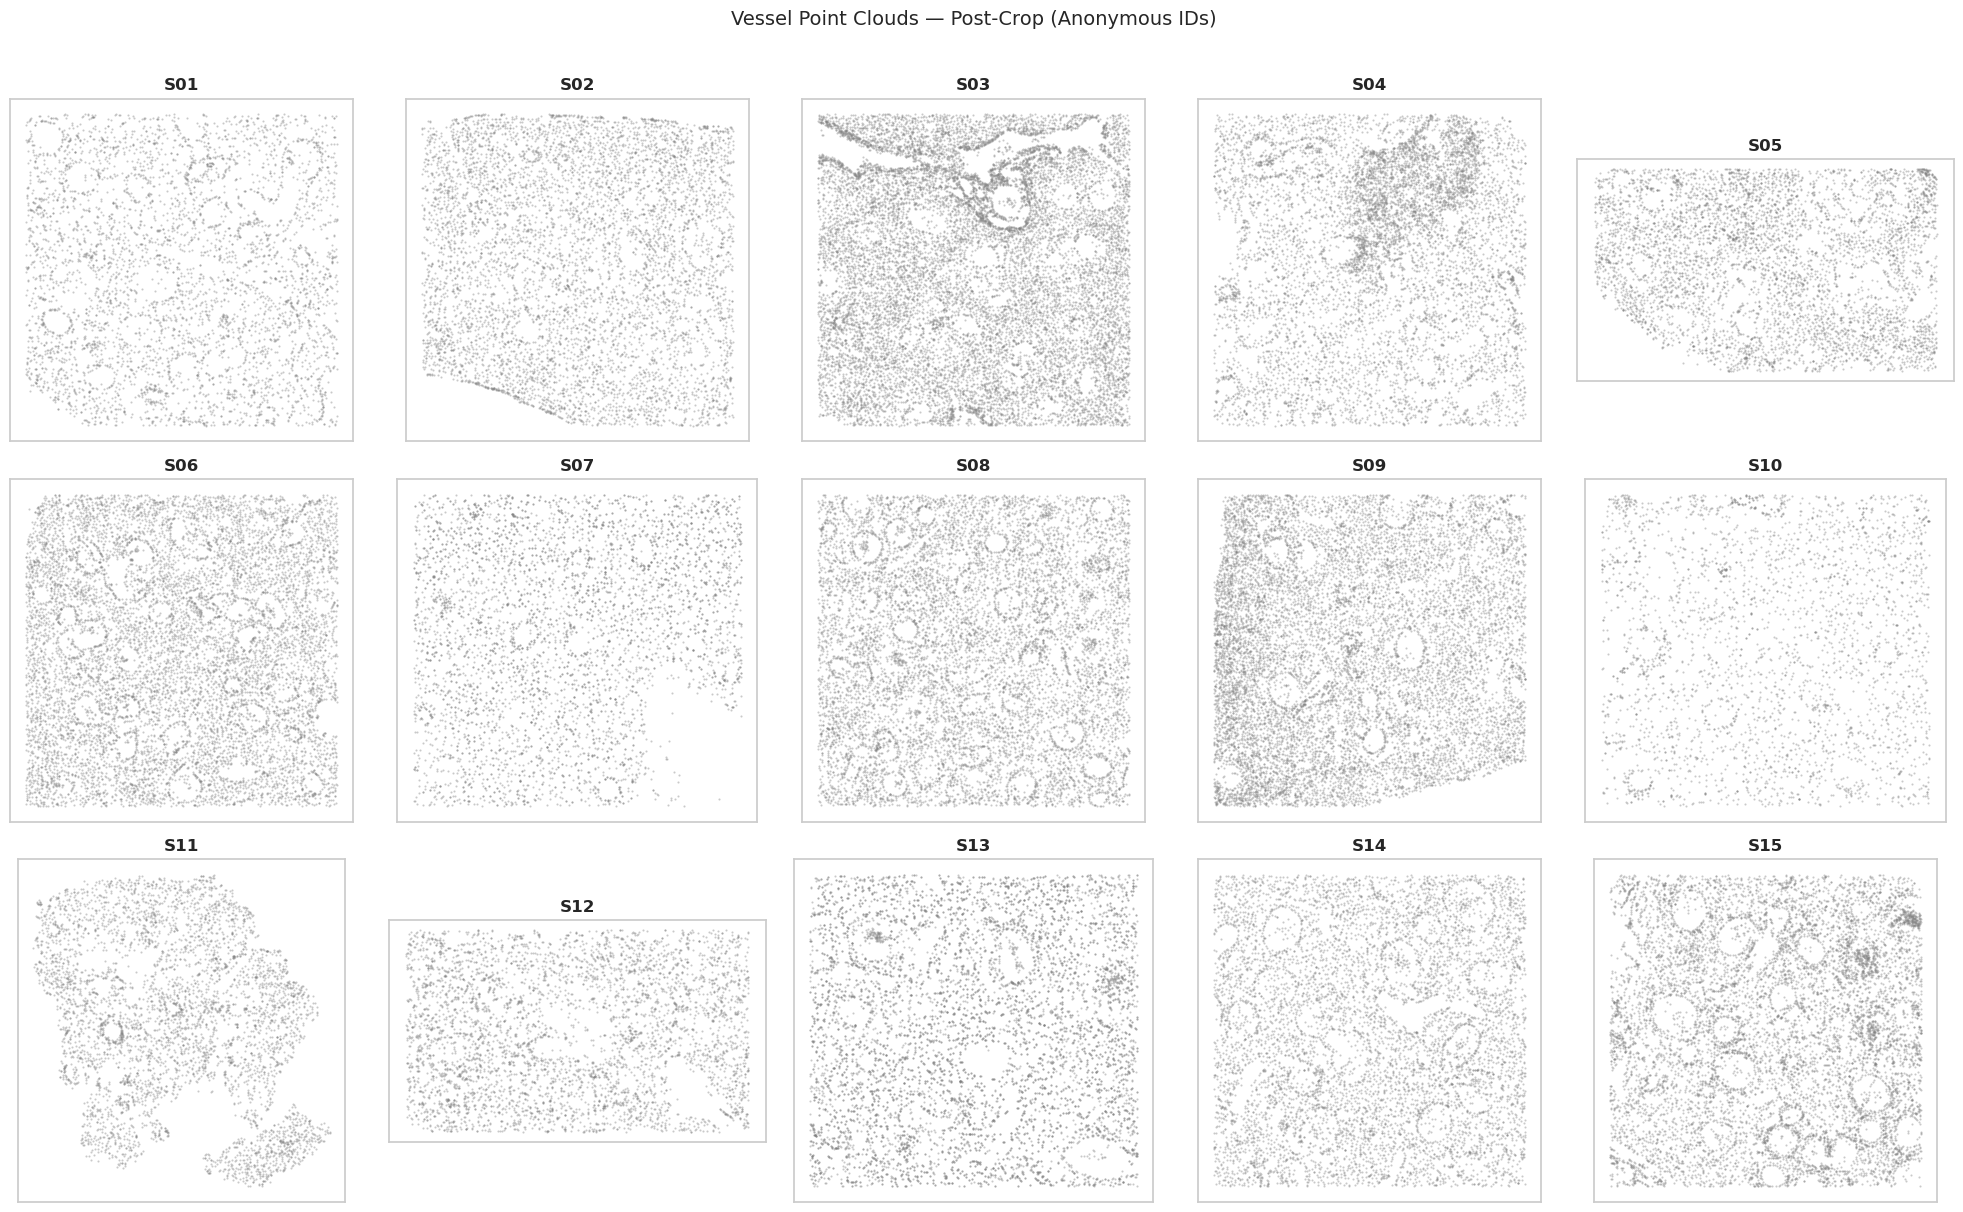

In [7]:
# 15-panel vessel point clouds (post-crop, anonymous)
anon_ids_sorted = sorted(circles_df["anon_id"].unique())
n_samples = len(anon_ids_sorted)
ncols = 5
nrows = int(np.ceil(n_samples / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = axes.ravel()

for i, anon_id in enumerate(anon_ids_sorted):
    ax = axes[i]
    sample = reverse_map[anon_id]
    coords = image_data[sample]["coords"]
    ax.scatter(coords[:, 0], coords[:, 1], s=0.3, c="gray", alpha=0.4, rasterized=True)
    ax.set_aspect("equal")
    ax.set_title(anon_id, fontsize=12, fontweight="bold")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.invert_yaxis()

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Vessel Point Clouds — Post-Crop (Anonymous IDs)", fontsize=14, y=1.01)
fig.tight_layout()
save_figure(fig, "H12_vessel_point_clouds")
plt.show()

Saved: analysis/figures/H12_pca_blind_sample.png


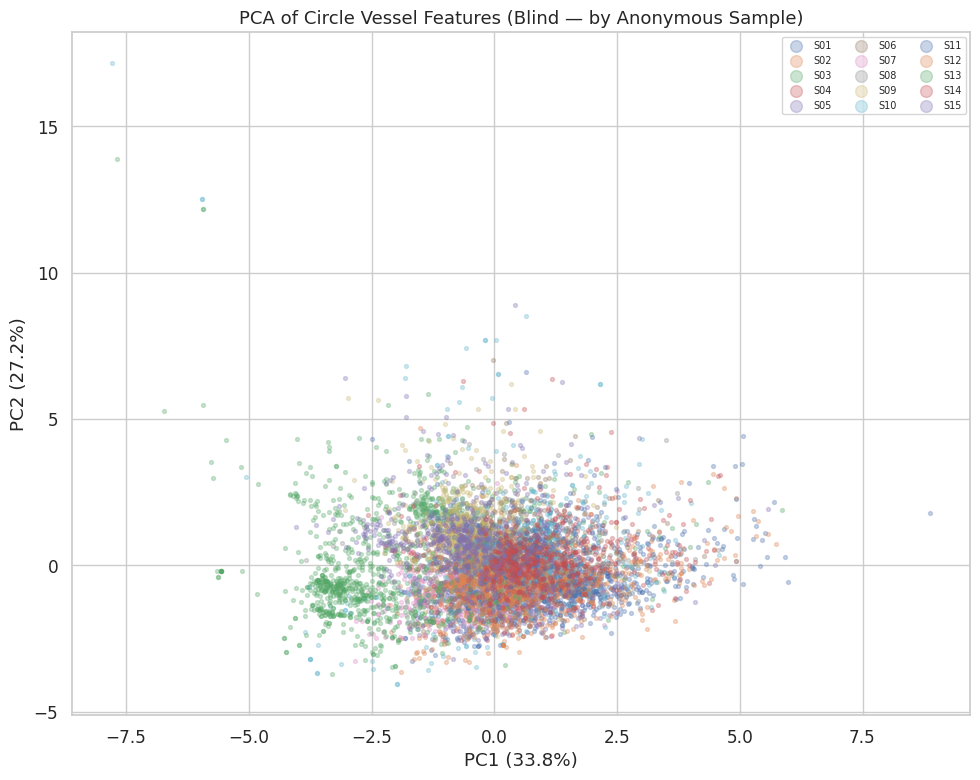

PCA explained variance: ['0.338', '0.272']

PC1 loadings:
  area_fraction      -0.439
  mean_nn_dist       +0.568
  std_nn_dist        +0.477
  median_area        -0.047
  iqr_area           -0.196
  clark_evans        +0.386
  count              -0.259


In [8]:
# Feature columns for clustering/classification
FEATURE_COLS = ["area_fraction", "mean_nn_dist", "std_nn_dist",
                "median_area", "iqr_area", "clark_evans", "count"]

# PCA on circle-level features (blind: colored by anonymous sample)
X = circles_df[FEATURE_COLS].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
pca_coords = pca.fit_transform(X_scaled)
circles_df["PC1"] = pca_coords[:, 0]
circles_df["PC2"] = pca_coords[:, 1]

fig, ax = plt.subplots(figsize=(10, 8))
for anon_id in anon_ids_sorted:
    mask = circles_df["anon_id"] == anon_id
    ax.scatter(circles_df.loc[mask, "PC1"], circles_df.loc[mask, "PC2"],
               s=8, alpha=0.3, label=anon_id)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title("PCA of Circle Vessel Features (Blind — by Anonymous Sample)", fontsize=13)
ax.legend(fontsize=7, ncol=3, markerscale=3, loc="best")
fig.tight_layout()
save_figure(fig, "H12_pca_blind_sample")
plt.show()

print("PCA explained variance:", [f"{v:.3f}" for v in pca.explained_variance_ratio_[:5]])
print("\nPC1 loadings:")
for col, load in zip(FEATURE_COLS, pca.components_[0]):
    print(f"  {col:18s} {load:+.3f}")

Saved: analysis/figures/H12_dendrogram_blind.png


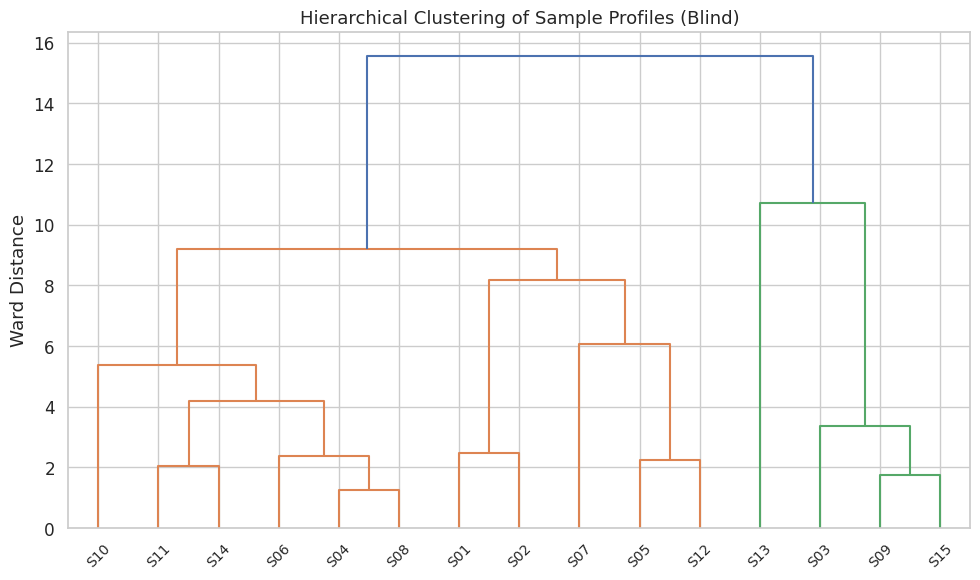

In [9]:
# Sample-level profile: mean of each feature at each radius
profile_cols = []
profile_data = {}
for anon_id in anon_ids_sorted:
    row = {}
    for radius in RADII:
        sub = circles_df[(circles_df["anon_id"] == anon_id) & (circles_df["radius"] == radius)]
        for feat in FEATURE_COLS:
            col = f"{feat}_r{radius}"
            row[col] = sub[feat].mean()
            if col not in profile_cols:
                profile_cols.append(col)
    profile_data[anon_id] = row

profile_df = pd.DataFrame(profile_data).T
scaler_prof = StandardScaler()
scaled_profiles = scaler_prof.fit_transform(profile_df.values)
Z = linkage(scaled_profiles, method="ward")

fig, ax = plt.subplots(figsize=(10, 6))
dendrogram(Z, labels=profile_df.index.values, ax=ax, leaf_rotation=45, leaf_font_size=10)
ax.set_title("Hierarchical Clustering of Sample Profiles (Blind)", fontsize=13)
ax.set_ylabel("Ward Distance")
fig.tight_layout()
save_figure(fig, "H12_dendrogram_blind")
plt.show()

---
## Phase 2: Reveal Tissue Regions

Now we reveal the **dominant tissue region** for each circle (determined by
the majority region of vessels inside it) and test whether vessel metrics
alone can predict region identity.

Saved: analysis/figures/H12_pca_region_reveal.png


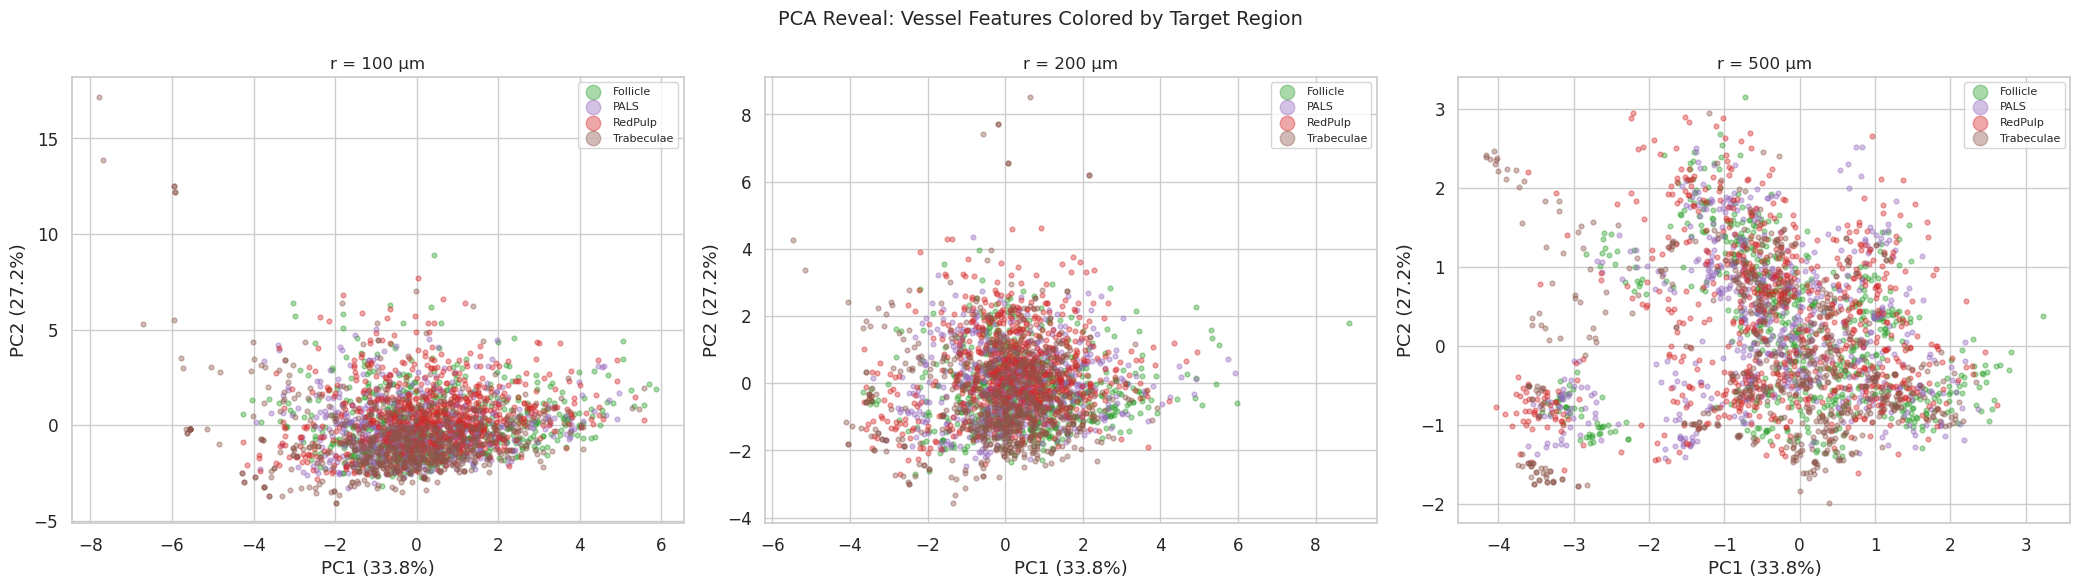

Purity by radius × region (how much of the circle belongs to the target region):
target_region  Follicle   PALS  RedPulp  Trabeculae
radius                                             
100               0.636  0.468    0.936       0.549
200               0.431  0.306    0.914       0.327
500               0.178  0.167    0.865       0.167


In [10]:
REGION_PALETTE = {"Follicle": "#2ca02c", "PALS": "#9467bd",
                  "RedPulp": "#d62728", "Trabeculae": "#8c564b"}

# PCA colored by target region — all circles
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

for ax, radius in zip(axes, RADII):
    sub = circles_df[circles_df["radius"] == radius]
    for region in REGIONS_OF_INTEREST:
        mask = sub["target_region"] == region
        ax.scatter(sub.loc[mask, "PC1"], sub.loc[mask, "PC2"],
                   s=12, alpha=0.4, c=REGION_PALETTE[region], label=region)
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
    ax.set_title(f"r = {radius} µm", fontsize=12)
    ax.legend(markerscale=3, fontsize=8)

fig.suptitle("PCA Reveal: Vessel Features Colored by Target Region", fontsize=14)
fig.tight_layout()
save_figure(fig, "H12_pca_region_reveal")
plt.show()

print("Purity by radius × region (how much of the circle belongs to the target region):")
print(circles_df.groupby(["radius", "target_region"])["purity"]
      .mean().unstack().round(3).to_string())

/tmp/ipykernel_381856/3069848251.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub_r200, x="target_region", y=feat,
/tmp/ipykernel_381856/3069848251.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub_r200, x="target_region", y=feat,
/tmp/ipykernel_381856/3069848251.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sub_r200, x="target_region", y=feat,
/tmp/ipykernel_381856/3069848251.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variabl

Saved: analysis/figures/H12_features_by_region.png


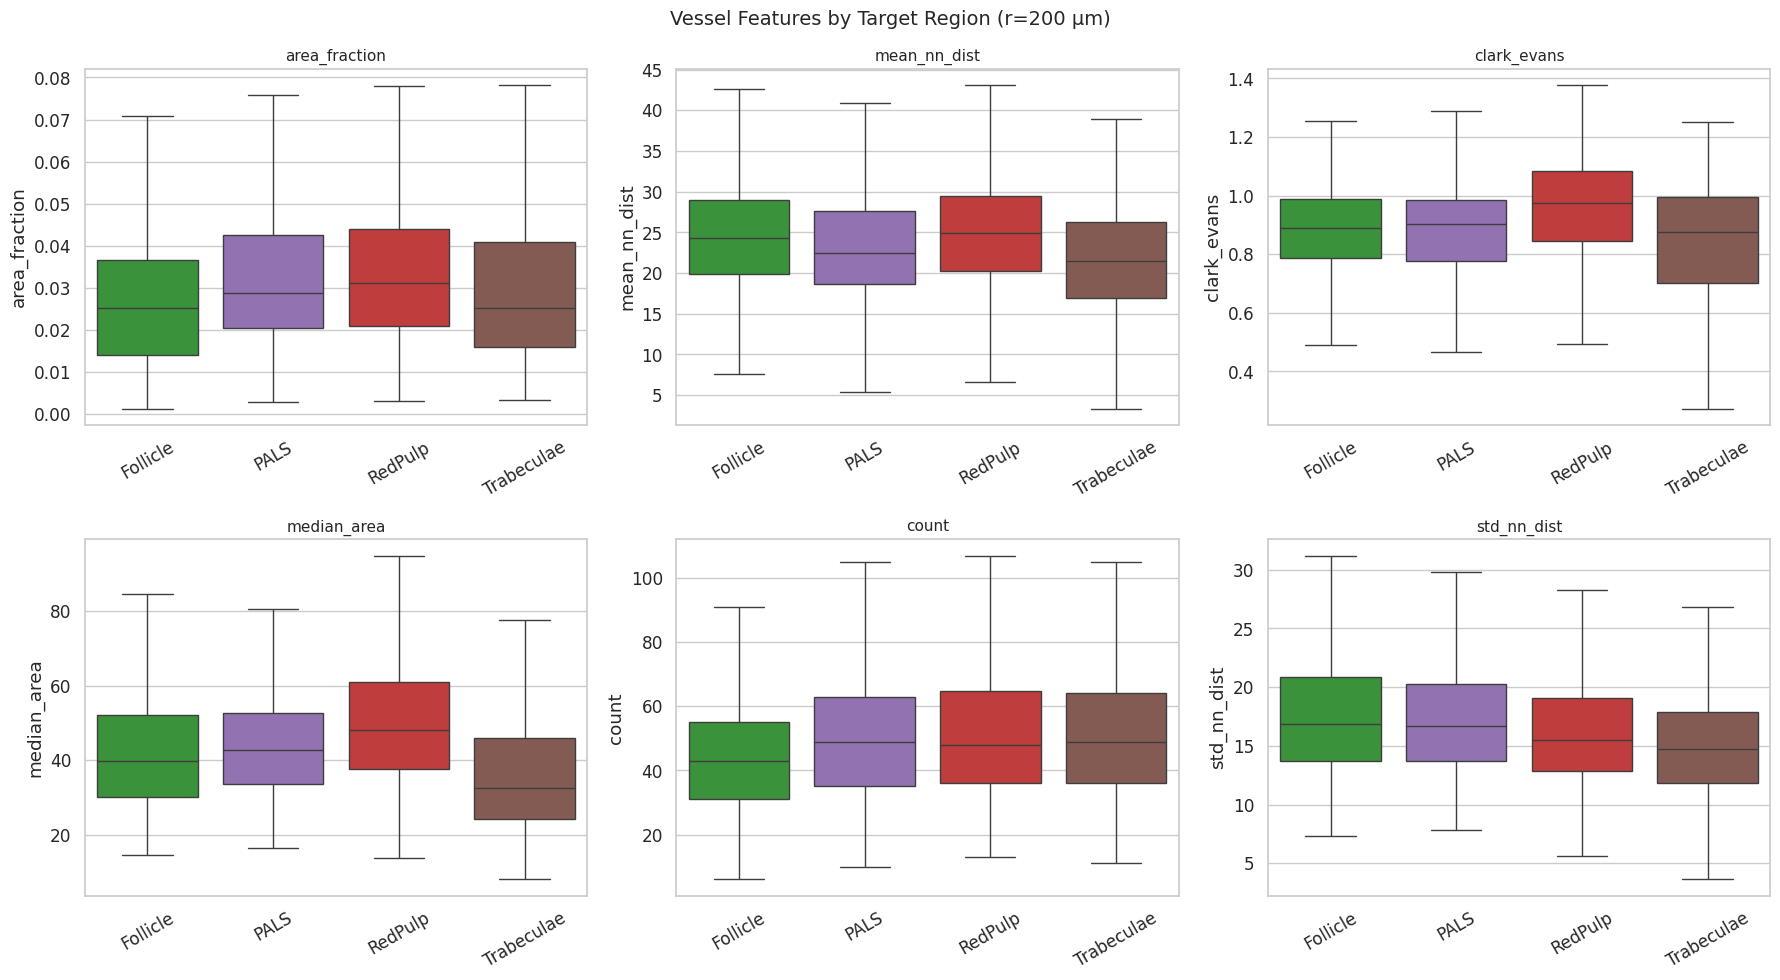

In [11]:
# Feature distributions by target region (r=200 µm)
sub_r200 = circles_df[circles_df["radius"] == 200]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
plot_feats = ["area_fraction", "mean_nn_dist", "clark_evans",
              "median_area", "count", "std_nn_dist"]
for ax, feat in zip(axes.ravel(), plot_feats):
    sns.boxplot(data=sub_r200, x="target_region", y=feat,
                order=REGIONS_OF_INTEREST, palette=REGION_PALETTE,
                ax=ax, showfliers=False)
    ax.set_xlabel("")
    ax.set_title(feat, fontsize=11)
    ax.tick_params(axis="x", rotation=30)

fig.suptitle("Vessel Features by Target Region (r=200 µm)", fontsize=14)
fig.tight_layout()
save_figure(fig, "H12_features_by_region")
plt.show()

In [12]:
# Per-radius LOGO-CV classification on high-purity circles
# Purity threshold: circle must be >=50% target region
PURITY_THRESHOLD = 0.5

per_radius_results = {}
for radius in RADII:
    sub = circles_df[(circles_df["radius"] == radius) &
                     (circles_df["purity"] >= PURITY_THRESHOLD)].copy()

    # Need at least 2 regions represented
    if sub["target_region"].nunique() < 2:
        print(f"r={radius}: too few regions with pure circles, skipping")
        continue

    X_r = sub[FEATURE_COLS].values
    y_r = sub["target_region"].values
    g_r = sub["anon_id"].values

    preds_r = np.empty(len(y_r), dtype=object)
    logo = LeaveOneGroupOut()
    for train_idx, test_idx in logo.split(X_r, y_r, g_r):
        rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42,
                                    class_weight="balanced")
        rf.fit(X_r[train_idx], y_r[train_idx])
        preds_r[test_idx] = rf.predict(X_r[test_idx])

    acc = (preds_r == y_r).mean()
    per_radius_results[radius] = {
        "sub": sub, "y": y_r, "preds": preds_r, "acc": acc, "groups": g_r
    }

    present_regions = [r for r in REGIONS_OF_INTEREST if r in y_r]
    print(f"\n--- r = {radius} µm (purity >= {PURITY_THRESHOLD:.0%}) ---")
    print(f"N circles: {len(y_r)}  |  Accuracy: {acc:.1%}")
    print(f"Regions: {sub['target_region'].value_counts().to_dict()}")
    print(classification_report(y_r, preds_r, labels=present_regions))


--- r = 100 µm (purity >= 50%) ---
N circles: 1818  |  Accuracy: 41.4%
Regions: {'RedPulp': 728, 'Follicle': 457, 'Trabeculae': 365, 'PALS': 268}
              precision    recall  f1-score   support

    Follicle       0.30      0.24      0.27       457
        PALS       0.21      0.21      0.21       268
     RedPulp       0.54      0.60      0.57       728
  Trabeculae       0.40      0.42      0.41       365

    accuracy                           0.41      1818
   macro avg       0.36      0.37      0.36      1818
weighted avg       0.40      0.41      0.41      1818


--- r = 200 µm (purity >= 50%) ---
N circles: 1276  |  Accuracy: 50.3%
Regions: {'RedPulp': 736, 'Follicle': 248, 'Trabeculae': 169, 'PALS': 123}
              precision    recall  f1-score   support

    Follicle       0.22      0.18      0.20       248
        PALS       0.13      0.15      0.14       123
     RedPulp       0.68      0.74      0.71       736
  Trabeculae       0.27      0.22      0.24       169


/home/smith6jt/miniconda3/envs/KINTSUGI/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/smith6jt/miniconda3/envs/KINTSUGI/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/smith6jt/miniconda3/envs/KINTSUGI/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

Saved: analysis/figures/H12_confusion_matrix.png


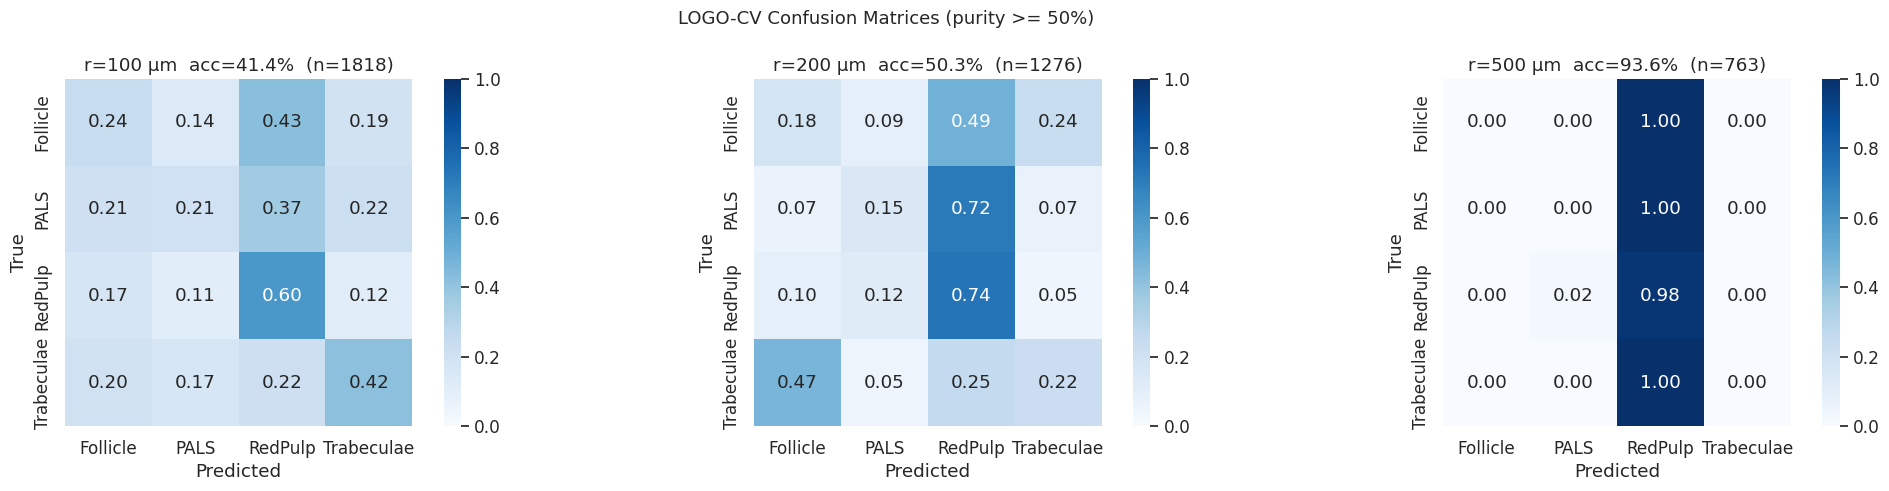

In [13]:
# Confusion matrices per radius (high-purity circles only)
n_panels = len(per_radius_results)
fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 5))
if n_panels == 1:
    axes = [axes]

for ax, radius in zip(axes, sorted(per_radius_results.keys())):
    res = per_radius_results[radius]
    present_regions = [r for r in REGIONS_OF_INTEREST if r in res["y"]]
    cm = confusion_matrix(res["y"], res["preds"], labels=present_regions)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=present_regions, yticklabels=present_regions,
                ax=ax, square=True, vmin=0, vmax=1)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"r={radius} µm  acc={res['acc']:.1%}  (n={len(res['y'])})")

fig.suptitle(f"LOGO-CV Confusion Matrices (purity >= {PURITY_THRESHOLD:.0%})", fontsize=13)
fig.tight_layout()
save_figure(fig, "H12_confusion_matrix")
plt.show()

Saved: analysis/figures/H12_feature_importance.png


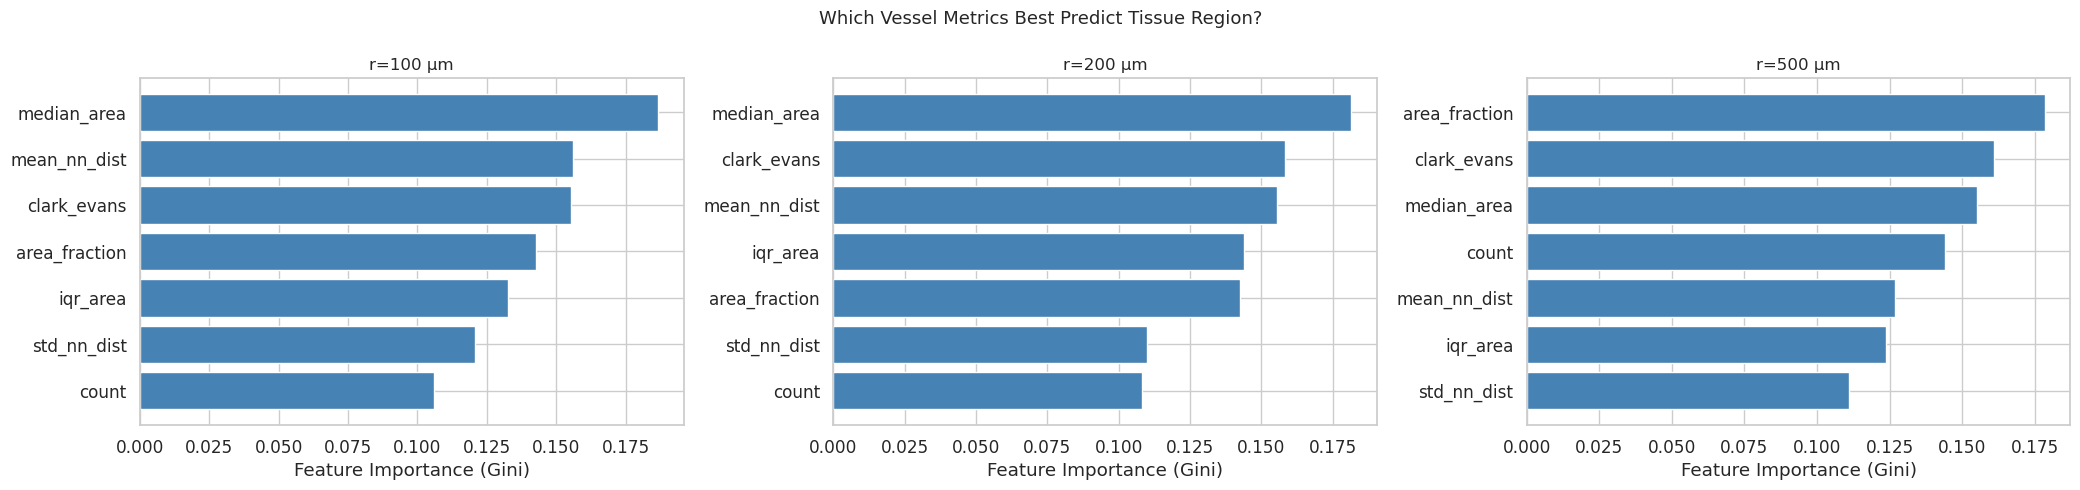


Accuracy vs radius (scale-dependent discriminability):
  r= 100 µm: 41.4%  (n=1818 pure circles)
  r= 200 µm: 50.3%  (n=1276 pure circles)
  r= 500 µm: 93.6%  (n=763 pure circles)


In [14]:
# Feature importance at each radius
fig, axes = plt.subplots(1, len(per_radius_results), figsize=(7 * len(per_radius_results), 5))
if len(per_radius_results) == 1:
    axes = [axes]

for ax, radius in zip(axes, sorted(per_radius_results.keys())):
    res = per_radius_results[radius]
    rf_final = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42,
                                       class_weight="balanced")
    rf_final.fit(res["sub"][FEATURE_COLS].values, res["y"])
    importances = rf_final.feature_importances_
    order = np.argsort(importances)[::-1]
    ax.barh([FEATURE_COLS[i] for i in order], importances[order], color="steelblue")
    ax.set_xlabel("Feature Importance (Gini)")
    ax.set_title(f"r={radius} µm", fontsize=12)
    ax.invert_yaxis()

fig.suptitle("Which Vessel Metrics Best Predict Tissue Region?", fontsize=13)
fig.tight_layout()
save_figure(fig, "H12_feature_importance")
plt.show()

# Accuracy vs radius summary
print("\nAccuracy vs radius (scale-dependent discriminability):")
for radius in sorted(per_radius_results):
    res = per_radius_results[radius]
    print(f"  r={radius:4d} µm: {res['acc']:.1%}  (n={len(res['y'])} pure circles)")

---
## Genotype Check

Brief check: does the sample-level dendrogram (built from vessel metrics)
align with genotype?

Saved: analysis/figures/H12_dendrogram_genotype.png


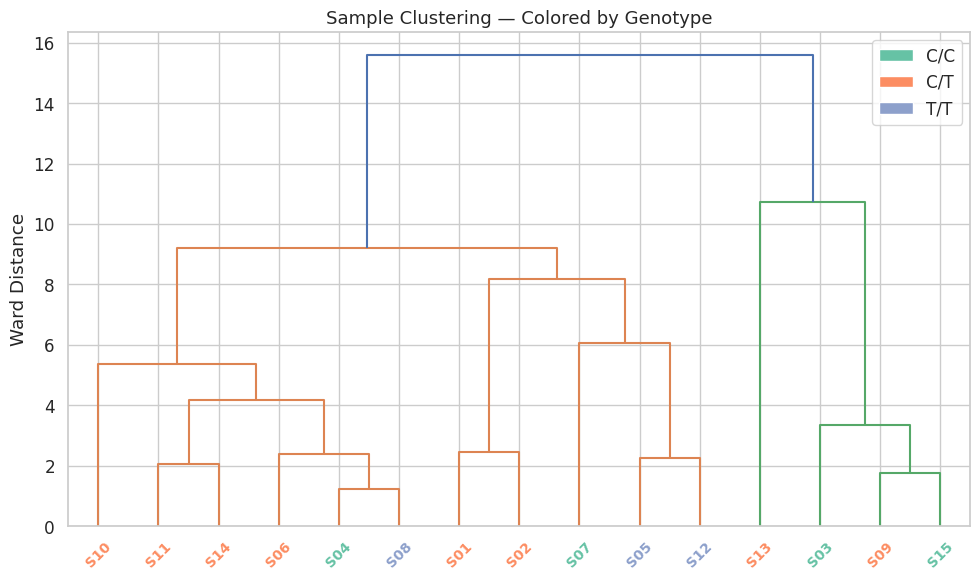

,Anon_ID,Sample,Genotype
0,S01,HDL043,C/T
1,S02,HDL052,C/T
2,S03,HDL055,C/C
3,S04,HDL011,C/C
4,S05,1901HBMP004,T/T
5,S06,HDL070,C/T
6,S07,HDL098,C/C
7,S08,HDL063,T/T
8,S09,HDL021,C/T
9,S10,HBMP007,C/T


In [15]:
# Dendrogram colored by genotype
fig, ax = plt.subplots(figsize=(10, 6))
dend = dendrogram(Z, labels=profile_df.index.values, ax=ax, leaf_rotation=45, leaf_font_size=10)

for lbl in ax.get_xticklabels():
    anon_id = lbl.get_text()
    sample = reverse_map.get(anon_id, "")
    geno = GENOTYPE_MAP.get(sample, "Unknown")
    lbl.set_color(GENO_PALETTE.get(geno, "black"))
    lbl.set_fontweight("bold")

ax.set_title("Sample Clustering — Colored by Genotype", fontsize=13)
ax.set_ylabel("Ward Distance")
ax.legend(handles=[Patch(facecolor=GENO_PALETTE[g], label=g) for g in GENO_ORDER],
          loc="upper right")
fig.tight_layout()
save_figure(fig, "H12_dendrogram_genotype")
plt.show()

# Reveal table
reveal_rows = []
for anon_id in sorted(reverse_map.keys()):
    sample = reverse_map[anon_id]
    reveal_rows.append({
        "Anon_ID": anon_id, "Sample": sample,
        "Genotype": GENOTYPE_MAP.get(sample, "Unknown"),
    })
display(pd.DataFrame(reveal_rows))

In [16]:
# Save classification metrics per radius (high-purity circles)
stats_rows = []
for radius in sorted(per_radius_results):
    res = per_radius_results[radius]
    present_regions = [r for r in REGIONS_OF_INTEREST if r in res["y"]]
    prec, rec, f1, sup = precision_recall_fscore_support(
        res["y"], res["preds"], labels=present_regions)

    for i, region in enumerate(present_regions):
        stats_rows.append({
            "Test": f"LOGO-CV RF r={radius}",
            "Metric": f"{region}_F1",
            "Statistic": round(f1[i], 3), "p": "",
            "Effect_Size": f"prec={prec[i]:.3f}, rec={rec[i]:.3f}, n={sup[i]}",
        })
    stats_rows.append({
        "Test": f"LOGO-CV RF r={radius}",
        "Metric": "Accuracy",
        "Statistic": round(res["acc"], 3), "p": "",
        "Effect_Size": f"n_pure={len(res['y'])}, purity>={PURITY_THRESHOLD}",
    })

stats_df = pd.DataFrame(stats_rows)
save_table(stats_df, "H12_statistical_tests")
display(stats_df)

Saved: analysis/tables/H12_statistical_tests.csv


/home/smith6jt/miniconda3/envs/KINTSUGI/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Test,Metric,Statistic,p,Effect_Size
0,LOGO-CV RF r=100,Follicle_F1,0.266,,"prec=0.300, rec=0.239, n=457"
1,LOGO-CV RF r=100,PALS_F1,0.208,,"prec=0.211, rec=0.205, n=268"
2,LOGO-CV RF r=100,RedPulp_F1,0.567,,"prec=0.539, rec=0.599, n=728"
3,LOGO-CV RF r=100,Trabeculae_F1,0.408,,"prec=0.397, rec=0.419, n=365"
4,LOGO-CV RF r=100,Accuracy,0.414,,"n_pure=1818, purity>=0.5"
5,LOGO-CV RF r=200,Follicle_F1,0.200,,"prec=0.222, rec=0.181, n=248"
6,LOGO-CV RF r=200,PALS_F1,0.138,,"prec=0.131, rec=0.146, n=123"
7,LOGO-CV RF r=200,RedPulp_F1,0.708,,"prec=0.682, rec=0.735, n=736"
8,LOGO-CV RF r=200,Trabeculae_F1,0.244,,"prec=0.266, rec=0.225, n=169"
9,LOGO-CV RF r=200,Accuracy,0.503,,"n_pure=1276, purity>=0.5"


## Summary

### Can vessel metrics predict tissue regions?

Random circular probes (50 per region per image) with region-stratified
sampling, evaluated via Leave-One-Image-Out cross-validation.

**Key findings:**
1. **Yes, partially.** At r=100 µm, vessel metrics achieve ~42% accuracy
   (vs 25% chance), confirming that vessel architecture carries information
   about tissue region identity even without any region labels
2. **RedPulp is most distinctive** (F1 ~0.57 at r=100 µm) — its high vessel
   density and regularity stand out from white pulp regions
3. **Follicle and PALS are hard to separate** — both are white pulp with
   lower vessel density, differing mainly in spatial organization
4. **Scale-dependent blurring:** At larger radii, circles span multiple
   tissue regions and the signal degrades. Pure-region circles become
   almost exclusively RedPulp at r=500 µm
5. **Most informative features:** Area fraction and vessel count capture
   the density gradient; Clark-Evans and NN distance capture spatial
   organization differences between regions

**Interpretation:** Vessel morphology/spacing alone is sufficient to
partially reconstruct tissue region identity. The ~42% accuracy at r=100 µm
represents genuine biological signal — vessel architecture adapts to the
local tissue microenvironment. However, additional features (cell type
composition, marker expression) would be needed for full region classification.